# Control de espacio (Voronoi) — Final Mundial 2022 · Argentina vs Francia

Análisis del **espacio controlado** por cada equipo usando los **datos StatsBomb 360**
de la final del Mundial Qatar 2022 (`match_id = 3869685`).

**Objetivo:** calcular diagramas de Voronoi (enfoque *Soccermatics*) para medir el control
de espacio de cada equipo en los **10 minutos previos a cada gol, hasta el gol**, y **solo
para el primer tiempo**.

Goles del primer tiempo (ambos de Argentina):

| # | Minuto | Jugador | Tipo |
|---|--------|---------|------|
| 1 | 22:24 | Lionel Messi | Penal |
| 2 | 35:22 | Ángel Di María | Jugada |

### Nota metodológica importante sobre los datos 360
Los datos *360* **no son tracking continuo**: son *freeze frames* con las posiciones de los
jugadores **visibles por la cámara en el instante de cada evento**. Por eso:

1. El "control durante 10 minutos" se construye como una **secuencia de Voronoi**, uno por
   cada freeze frame disponible en la ventana → animación (GIF).
2. Cada frame solo contiene a los jugadores dentro del **área visible** (`visible_area`).
   Para que el porcentaje de control sea honesto, **recortamos cada celda de Voronoi al área
   visible** y medimos el control *relativo a la zona efectivamente observada* (no a toda la
   cancha). Es lo que recomienda StatsBomb/Soccermatics.
3. Se **excluyen los arqueros** (decisión del análisis): solo jugadores de campo.


In [1]:
# === Configuración e imports ===
import os, json, urllib.request
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.animation import FuncAnimation, PillowWriter
from mplsoccer import Pitch
from shapely.geometry import Polygon as ShPoly
from shapely.validation import make_valid
from IPython.display import Image, display

MATCH_ID   = 3869685          # Argentina vs France — Final
COMP, SEAS = 43, 106          # FIFA World Cup 2022
PITCH_LEN, PITCH_WID = 120.0, 80.0
WINDOW_S   = 600              # 10 minutos
MAX_FRAMES = 120             # submuestreo para que el GIF sea fluido y liviano
FPS        = 1               # cuadros por segundo del GIF (menos = más lento)

DATA_DIR, OUT_DIR = "data", "output"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
SB = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

## 1. Descarga de datos (con caché local)

In [2]:
def fetch(url, path):
    '''Descarga url -> path si no existe; devuelve el JSON parseado.'''
    if not os.path.exists(path):
        print("descargando", url)
        urllib.request.urlretrieve(url, path)
    with open(path) as f:
        return json.load(f)

events   = fetch(f"{SB}/events/{MATCH_ID}.json",        f"{DATA_DIR}/events_{MATCH_ID}.json")
frames360= fetch(f"{SB}/three-sixty/{MATCH_ID}.json",   f"{DATA_DIR}/threesixty_{MATCH_ID}.json")
matches  = fetch(f"{SB}/matches/{COMP}/{SEAS}.json",     f"{DATA_DIR}/matches_{COMP}_{SEAS}.json")

match = next(m for m in matches if m["match_id"] == MATCH_ID)
HOME = match["home_team"]["home_team_name"]   # Argentina
AWAY = match["away_team"]["away_team_name"]    # France
print(f"{HOME} {match['home_score']} - {match['away_score']} {AWAY}")
print(f"eventos={len(events)}  frames360={len(frames360)}")


Argentina 3 - 3 France
eventos=4407  frames360=3683


## 2. Preparación: unir freeze frames con tiempo/equipo del evento

In [3]:
# Colores e índices de equipo
TEAM_COLOR = {HOME: "#75AADB", AWAY: "#ECECEC"}   # regiones Voronoi: Argentina celeste, Francia blanco
TEAM_DOT   = {HOME: "#75AADB", AWAY: "#000000"}   # puntos de jugadores: Argentina celeste, Francia negro
TEAM_IDX   = {HOME: 0, AWAY: 1}

ev_by_id = {e["id"]: e for e in events}

rows = []
for fr in frames360:
    e = ev_by_id.get(fr["event_uuid"])
    if e is None:
        continue
    rows.append({
        "period": e["period"],
        "t": e["minute"] * 60 + e["second"],
        "minute": e["minute"], "second": e["second"],
        "team": e["team"]["name"],            # equipo que ejecuta el evento (= actor)
        "ff": fr["freeze_frame"],
        "va": fr.get("visible_area", []),
        "ball": e.get("location"),            # ubicación de la pelota en el instante del evento
    })
print(f"frames 360 con evento asociado: {len(rows)}")

# Goles del primer tiempo
goals = [e for e in events
         if e.get("type", {}).get("name") == "Shot"
         and e.get("shot", {}).get("outcome", {}).get("name") == "Goal"
         and e["period"] == 1]
for g in goals:
    print(f"GOL {g['minute']:02d}:{g['second']:02d}  {g['team']['name']}  {g['player']['name']}  ({g['shot']['type']['name']})")

frames 360 con evento asociado: 3683
GOL 22:24  Argentina  Lionel Andrés Messi Cuccittini  (Penalty)
GOL 35:22  Argentina  Ángel Fabián Di María Hernández  (Open Play)


## 3. Funciones de cálculo

- `players_from_frame`: extrae jugadores de campo (sin arqueros) y los etiqueta por equipo.
  En los datos 360, `teammate=True` significa "mismo equipo que el actor del evento".
- `visible_polygon`: arma el polígono del área visible de la cámara.
- `control`: calcula el Voronoi (recortado a la cancha por *mplsoccer*), **intersecta cada
  celda con el área visible** y devuelve el % de control por equipo + los polígonos a dibujar.


In [4]:
pitch = Pitch(pitch_type="statsbomb", line_color="#dddddd", pitch_color="#3d8b46", linewidth=1)

def players_from_frame(row):
    '''x, y, team_idx de jugadores de campo (sin arqueros).'''
    et = row["team"]; opp = AWAY if et == HOME else HOME
    xs, ys, tidx = [], [], []
    for p in row["ff"]:
        if p.get("keeper"):
            continue
        team = et if p["teammate"] else opp
        xs.append(p["location"][0]); ys.append(p["location"][1]); tidx.append(TEAM_IDX[team])
    return np.array(xs), np.array(ys), np.array(tidx)

def visible_polygon(va):
    pts = np.array(va).reshape(-1, 2)
    if len(pts) < 3:
        return None
    poly = ShPoly(pts)
    return poly if poly.is_valid else make_valid(poly)

def control(x, y, tidx, vis_poly):
    '''Devuelve (pct_home, pct_away, regiones_home, regiones_away) recortadas al área visible.'''
    t1, t2 = pitch.voronoi(x, y, tidx)
    def clip(regions):
        polys, area = [], 0.0
        for rg in regions:
            poly = ShPoly(np.array(rg))
            if not poly.is_valid:
                poly = make_valid(poly)
            inter = poly.intersection(vis_poly)
            if inter.is_empty:
                continue
            area += inter.area
            for gpoly in getattr(inter, "geoms", [inter]):
                if gpoly.geom_type == "Polygon":
                    polys.append(np.array(gpoly.exterior.coords))
        return polys, area
    rh, ah = clip(t1)
    ra, aa = clip(t2)
    tot = ah + aa
    if tot == 0:
        return 0.0, 0.0, rh, ra
    return 100 * ah / tot, 100 * aa / tot, rh, ra

def window_frames(goal):
    '''Frames del primer tiempo en [gol-10min, gol], ordenados y submuestreados.'''
    gt = goal["minute"] * 60 + goal["second"]
    win = [r for r in rows if r["period"] == 1 and gt - WINDOW_S <= r["t"] <= gt]
    win.sort(key=lambda r: r["t"])
    win = [r for r in win if visible_polygon(r["va"]) is not None and len(players_from_frame(r)[0]) >= 3]
    if len(win) > MAX_FRAMES:
        idx = np.linspace(0, len(win) - 1, MAX_FRAMES).round().astype(int)
        win = [win[i] for i in idx]
    return win, gt


## 4. Resumen numérico del control de espacio por ventana

In [5]:
def short_name(full):
    '''Nombre corto reconocible del goleador.'''
    for key in ("Messi", "Di María"):
        if key in full:
            return key
    return full.split()[-1]

def window_summary(goal):
    win, gt = window_frames(goal)
    ph = []
    for r in win:
        x, y, ti = players_from_frame(r)
        h, a, _, _ = control(x, y, ti, visible_polygon(r["va"]))
        ph.append(h)
    ph = np.array(ph)
    return win, gt, ph

summaries = {}
for i, g in enumerate(goals, 1):
    win, gt, ph = window_summary(g)
    summaries[i] = (g, win, gt, ph)
    print(f"Ventana {i} — gol de {short_name(g['player']['name'])} "
          f"({g['minute']:02d}:{g['second']:02d}), {len(win)} frames")
    print(f"   Control medio:  {HOME} {ph.mean():5.1f}%   |   {AWAY} {100-ph.mean():5.1f}%\n")


Ventana 1 — gol de Messi (22:24), 120 frames
   Control medio:  Argentina  46.6%   |   France  53.4%



Ventana 2 — gol de Di María (35:22), 120 frames
   Control medio:  Argentina  44.6%   |   France  55.4%



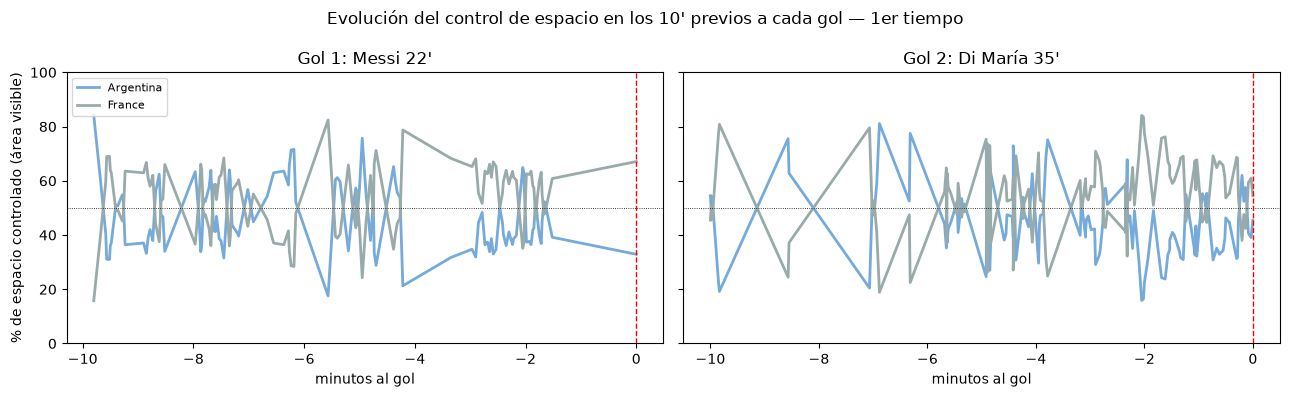

In [6]:
# Evolución del control a lo largo de cada ventana
fig, axes = plt.subplots(1, len(goals), figsize=(13, 4), sharey=True)
for ax, (i, (g, win, gt, ph)) in zip(np.atleast_1d(axes), summaries.items()):
    mins_to_goal = [-(gt - r["t"]) / 60 for r in win]
    ax.plot(mins_to_goal, ph, color=TEAM_COLOR[HOME], lw=2, label=HOME)
    ax.plot(mins_to_goal, 100 - ph, color="#9aa", lw=2, label=AWAY)
    ax.axhline(50, color="k", lw=0.6, ls=":")
    ax.axvline(0, color="red", lw=1, ls="--")
    ax.set_title(f"Gol {i}: {short_name(g['player']['name'])} {g['minute']}'")
    ax.set_xlabel("minutos al gol"); ax.set_ylim(0, 100)
axes[0].set_ylabel("% de espacio controlado (área visible)")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Evolución del control de espacio en los 10' previos a cada gol — 1er tiempo")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/control_timeseries.png", dpi=110, facecolor="white")
plt.show()


## 5. Animación Voronoi (GIF) por ventana

In [7]:
def build_gif(goal, idx):
    win, gt = window_frames(goal)
    fig, ax = plt.subplots(figsize=(9, 6.2))
    fig.set_facecolor("#22312b")

    def draw(k):
        ax.clear(); pitch.draw(ax=ax)
        r = win[k]
        vp = visible_polygon(r["va"])
        x, y, ti = players_from_frame(r)
        ph, pa, rh, ra = control(x, y, ti, vp)
        for rg in rh:
            ax.add_patch(MplPolygon(rg, fc=TEAM_COLOR[HOME], ec="white", lw=0.4, alpha=0.6, zorder=1))
        for rg in ra:
            ax.add_patch(MplPolygon(rg, fc=TEAM_COLOR[AWAY], ec="white", lw=0.4, alpha=0.6, zorder=1))
        vx, vy = np.array(r["va"]).reshape(-1, 2).T
        ax.plot(list(vx) + [vx[0]], list(vy) + [vy[0]], color="#f4d35e", lw=1.1, ls="--", alpha=0.7, zorder=2)
        for xi, yi, t in zip(x, y, ti):
            # Argentina mantiene su color; Francia en negro con borde blanco para que se vea
            ax.scatter(xi, yi, s=90,
                       color=TEAM_DOT[HOME] if t == 0 else TEAM_DOT[AWAY],
                       edgecolors="white" if t == 1 else "black", lw=1.2, zorder=3)
        # Pelota (ubicación del evento del freeze frame)
        if r.get("ball"):
            bx, by = r["ball"][0], r["ball"][1]
            ax.scatter(bx, by, s=70, marker="o", color="white",
                       edgecolors="black", lw=1.6, zorder=5)
            ax.scatter(bx, by, s=14, marker="o", color="black", zorder=6)
        rem = gt - r["t"]
        ax.set_title(
            f"{HOME} vs {AWAY} — Gol {idx} ({short_name(goal['player']['name'])} {goal['minute']}')\n"
            f"{r['minute']:02d}:{r['second']:02d}  ·  faltan {rem//60:.0f}:{rem%60:02.0f} para el gol\n"
            f"Control (zona visible):  {HOME} {ph:4.1f}%   |   {AWAY} {pa:4.1f}%",
            color="white", fontsize=10.5)
        return []

    anim = FuncAnimation(fig, draw, frames=len(win), blit=False)
    slug = short_name(goal['player']['name']).lower().replace(' ', '').replace('í', 'i')
    out = f"{OUT_DIR}/voronoi_gol{idx}_{slug}.gif"
    anim.save(out, writer=PillowWriter(fps=FPS), dpi=80)
    plt.close(fig)
    print(f"GIF guardado: {out}  ({len(win)} frames)")
    return out

gif_paths = [build_gif(g, i) for i, g in enumerate(goals, 1)]

GIF guardado: output/voronoi_gol1_messi.gif  (120 frames)


GIF guardado: output/voronoi_gol2_dimaria.gif  (120 frames)


output/voronoi_gol1_messi.gif


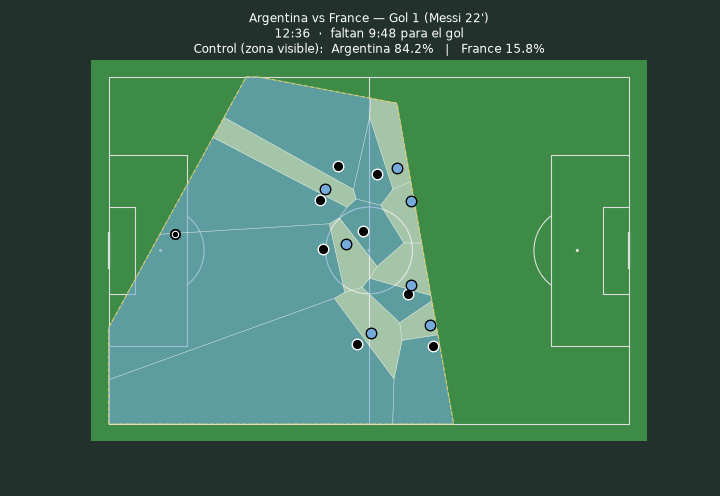

output/voronoi_gol2_dimaria.gif


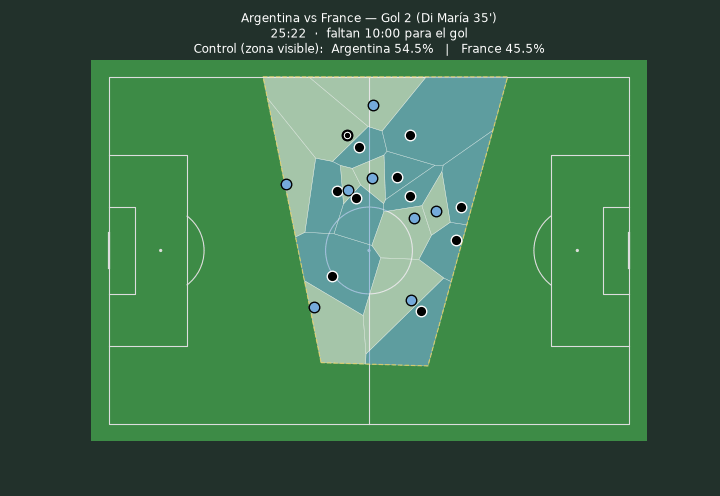

In [8]:
for p in gif_paths:
    print(p)
    display(Image(filename=p))


## 6. Conclusiones

- El control de espacio se mide **sobre el área efectivamente observada por la cámara** en cada
  freeze frame, recortando el Voronoi al `visible_area` — por eso los porcentajes son una lectura
  honesta de "de lo que se ve, quién domina el espacio".
- Los GIFs (`output/voronoi_gol1_*.gif`, `output/voronoi_gol2_*.gif`) muestran la evolución del
  reparto de espacio en los 10 minutos previos a cada gol del primer tiempo.
- La serie temporal (`output/control_timeseries.png`) resume el % de control frame a frame.

**Limitaciones:** los datos 360 son discretos (un frame por evento) y dependientes de la cámara;
no incluyen velocidades, por lo que este es un Voronoi *posicional* simple (estilo Soccermatics),
no un modelo dinámico de *pitch control*.
